# Auto ARIMA Benchmark

Every automatic-ARIMA implementation on the M1 + M3 + Tourism series, scored on
the **same** metrics as the ETS benchmark: point accuracy (**RMSSE**, **SAME**),
**computational time**, and the predictive distribution (**calibration** /
reliability at levels `seq(0.01, 0.99, 0.01)` and **scaled pinball** loss).

Methods:

- **smooth `AutoMSARIMA`** — backcasting / optimal / two-stage initialisation.
- **statsforecast `AutoARIMA`**, **skforecast `Arima`** (auto), **aeon `AutoARIMA`**.

Quantiles come from each package's predictive distribution; **aeon exposes no
quantile API**, so its calibration/pinball are `NaN`. The heavy fit+forecast run
(one fit per series produces point **and** 99 quantiles) lives in
`run_arima_benchmark.py`. Because auto-ARIMA order search (pmdarima especially)
is far heavier than AutoETS, the saved run uses the **full** M1+M3+Tourism set (sktime/pmdarima were dropped for being prohibitively slow; set `BENCH_N` to subsample).

In [1]:
import glob, os, subprocess, sys
import numpy as np, pandas as pd
pd.set_option("display.width", 200)

LEVELS = np.round(np.arange(0.01, 1.0, 0.01), 2)
METHOD_NAMES = ["AutoMSARIMA Back", "AutoMSARIMA Opt", "AutoMSARIMA Two",
                "statsforecast AutoARIMA", "skforecast Arima", "aeon AutoARIMA"]

# Recompute only if asked; otherwise load the saved results.
if os.environ.get("BENCH_RERUN_ARIMA", "0") == "1":
    subprocess.run([sys.executable, "run_arima_benchmark.py"], check=True)

pt_file = sorted(glob.glob("*-benchmark-arima-point.npy"))[-1]
di_file = sorted(glob.glob("*-benchmark-arima-dist.npy"))[-1]
point_results = np.load(pt_file)          # (M, N, 3) rmsse, same, time
dist_results  = np.load(di_file)          # (M, N, 99, 2) scaled pinball, coverage
n_methods = point_results.shape[0]; n_series = point_results.shape[1]
print(f"loaded {pt_file} and {di_file}")
print(f"methods={n_methods}  series (all 5315 series)={n_series}")
assert n_methods == len(METHOD_NAMES)


loaded 2026-07-23-benchmark-arima-point.npy and 2026-07-23-benchmark-arima-dist.npy
methods=6  series (all 5315 series)=5315


## Point accuracy & time

In [2]:
mi = 0
summary = pd.DataFrame({
    "Method": METHOD_NAMES,
    "Min": [np.nanmin(point_results[j, :, mi]) for j in range(n_methods)],
    "Q1": [np.nanquantile(point_results[j, :, mi], 0.25) for j in range(n_methods)],
    "Med": [np.nanmedian(point_results[j, :, mi]) for j in range(n_methods)],
    "Q3": [np.nanquantile(point_results[j, :, mi], 0.75) for j in range(n_methods)],
    "Max": [np.nanmax(point_results[j, :, mi]) for j in range(n_methods)],
    "Mean": [np.nanmean(point_results[j, :, mi]) for j in range(n_methods)],
    "Mean Time (s)": [np.nanmean(point_results[j, :, 2]) for j in range(n_methods)],
    "Failed": [int(np.sum(np.isnan(point_results[j, :, mi]))) for j in range(n_methods)],
}).sort_values("Mean")
print("\n" + "=" * 92 + "\nRMSSE (all 5315 series)\n" + "=" * 92)
print(summary.to_string(index=False, float_format=lambda x: f"{x:.4f}"))



RMSSE (all 5315 series)
                 Method    Min     Q1    Med     Q3       Max   Mean  Mean Time (s)  Failed
statsforecast AutoARIMA 0.0246 0.6827 1.1855 2.3533   51.6160 1.9812         1.3391       1
       AutoMSARIMA Back 0.0246 0.6849 1.1849 2.3830   51.6160 2.0155         1.6131       0
        AutoMSARIMA Opt 0.0246 0.7228 1.2451 2.4840   51.6160 2.0768         2.0967       0
        AutoMSARIMA Two 0.0605 0.8772 1.4198 2.5654   49.1362 2.2492         2.2386       0
       skforecast Arima 0.1003 1.1323 1.9424 3.2757   52.5829 2.6529         0.0321       0
         aeon AutoARIMA 0.0265 0.9010 1.4945 2.7265 1869.9910 2.8316         0.0168       0


In [3]:
mi = 1
summary = pd.DataFrame({
    "Method": METHOD_NAMES,
    "Min": [np.nanmin(point_results[j, :, mi]) for j in range(n_methods)],
    "Q1": [np.nanquantile(point_results[j, :, mi], 0.25) for j in range(n_methods)],
    "Med": [np.nanmedian(point_results[j, :, mi]) for j in range(n_methods)],
    "Q3": [np.nanquantile(point_results[j, :, mi], 0.75) for j in range(n_methods)],
    "Max": [np.nanmax(point_results[j, :, mi]) for j in range(n_methods)],
    "Mean": [np.nanmean(point_results[j, :, mi]) for j in range(n_methods)],
    "Mean Time (s)": [np.nanmean(point_results[j, :, 2]) for j in range(n_methods)],
    "Failed": [int(np.sum(np.isnan(point_results[j, :, mi]))) for j in range(n_methods)],
}).sort_values("Mean")
print("\n" + "=" * 92 + "\nSAME (all 5315 series)\n" + "=" * 92)
print(summary.to_string(index=False, float_format=lambda x: f"{x:.4f}"))



SAME (all 5315 series)
                 Method    Min     Q1    Med     Q3       Max   Mean  Mean Time (s)  Failed
statsforecast AutoARIMA 0.0000 0.4051 1.0499 2.4330   53.2685 2.0341         1.3391       1
       AutoMSARIMA Back 0.0000 0.3953 1.0239 2.5062   63.9676 2.0635         1.6131       0
        AutoMSARIMA Opt 0.0000 0.4207 1.0908 2.6229   53.3201 2.1434         2.0967       0
        AutoMSARIMA Two 0.0004 0.5242 1.2082 2.7012   82.2191 2.2649         2.2386       0
         aeon AutoARIMA 0.0006 0.5047 1.2526 2.8577 1370.9123 2.7410         0.0168       0
       skforecast Arima 0.0007 0.8964 1.9436 3.6890   55.6719 2.8125         0.0321       0


In [4]:
mi = 2
summary = pd.DataFrame({
    "Method": METHOD_NAMES,
    "Min": [np.nanmin(point_results[j, :, mi]) for j in range(n_methods)],
    "Q1": [np.nanquantile(point_results[j, :, mi], 0.25) for j in range(n_methods)],
    "Med": [np.nanmedian(point_results[j, :, mi]) for j in range(n_methods)],
    "Q3": [np.nanquantile(point_results[j, :, mi], 0.75) for j in range(n_methods)],
    "Max": [np.nanmax(point_results[j, :, mi]) for j in range(n_methods)],
    "Mean": [np.nanmean(point_results[j, :, mi]) for j in range(n_methods)],
    "Total (min)": [np.nansum(point_results[j, :, 2]) / 60 for j in range(n_methods)],
    "Failed": [int(np.sum(np.isnan(point_results[j, :, mi]))) for j in range(n_methods)],
}).sort_values("Mean")
print("\n" + "=" * 92 + "\nComputational time, seconds (all 5315 series)\n" + "=" * 92)
print(summary.to_string(index=False, float_format=lambda x: f"{x:.4f}"))



Computational time, seconds (all 5315 series)
                 Method    Min     Q1    Med     Q3     Max   Mean  Total (min)  Failed
         aeon AutoARIMA 0.0014 0.0112 0.0143 0.0186  0.1942 0.0168       1.4847       0
       skforecast Arima 0.0059 0.0147 0.0294 0.0398  0.5743 0.0321       2.8478       0
statsforecast AutoARIMA 0.0308 0.2628 0.5229 1.2208 49.6490 1.3391     118.6034       1
       AutoMSARIMA Back 0.0558 0.2011 0.4156 1.0808 57.0059 1.6131     142.8908       0
        AutoMSARIMA Opt 0.1425 0.4077 1.8385 3.0567 11.7948 2.0967     185.7319       0
        AutoMSARIMA Two 0.1473 0.4683 0.7516 1.6973 38.9895 2.2386     198.3068       0


## Predictive distribution: calibration + pinball

In [5]:
_pin = dist_results[:, :, :, 0]           # scaled pinball (M, N, 99)
_cov = dist_results[:, :, :, 1]           # coverage       (M, N, 99)
_pin_series = np.nanmean(_pin, axis=2)    # (M, N) mean over levels

rows = []
for j, name in enumerate(METHOD_NAMES):
    cov_curve = np.nanmean(_cov[j], axis=0)
    if np.all(np.isnan(cov_curve)):
        rows.append({"Method": name, "Mean Pinball": np.nan, "Median Pinball": np.nan,
                     "MCE": np.nan, "Cov@0.1": np.nan, "Cov@0.5": np.nan,
                     "Cov@0.9": np.nan, "n": 0})
        continue
    rows.append({"Method": name,
                 "Mean Pinball": np.nanmean(_pin[j]),
                 "Median Pinball": np.nanmedian(_pin_series[j]),
                 "MCE": np.nanmean(np.abs(cov_curve - LEVELS)),
                 "Cov@0.1": cov_curve[9], "Cov@0.5": cov_curve[49], "Cov@0.9": cov_curve[89],
                 "n": int(np.sum(~np.isnan(_pin_series[j])))})
summary_dist = pd.DataFrame(rows).sort_values("Median Pinball")
print("\n" + "=" * 100)
print("PREDICTIVE DISTRIBUTION: scaled pinball + calibration MCE (lower=better)")
print("=" * 100)
print(summary_dist.to_string(index=False, float_format=lambda x: f"{x:.4f}"))



PREDICTIVE DISTRIBUTION: scaled pinball + calibration MCE (lower=better)
                 Method  Mean Pinball  Median Pinball    MCE  Cov@0.1  Cov@0.5  Cov@0.9    n
statsforecast AutoARIMA        0.8884          0.4917 0.0357   0.1486   0.4828   0.8304 5314
       AutoMSARIMA Back        0.9031          0.4960 0.0329   0.1355   0.4762   0.8336 5315
        AutoMSARIMA Opt        0.9475          0.5176 0.0309   0.1358   0.4825   0.8339 5315
        AutoMSARIMA Two        1.0085          0.5902 0.0393   0.1646   0.5184   0.8354 5315
       skforecast Arima        1.1840          0.7736 0.1343   0.0890   0.3481   0.6770 5315
         aeon AutoARIMA           NaN             NaN    NaN      NaN      NaN      NaN    0


/tmp/ipykernel_210906/693729368.py:3: RuntimeWarning: Mean of empty slice
  _pin_series = np.nanmean(_pin, axis=2)    # (M, N) mean over levels
/tmp/ipykernel_210906/693729368.py:7: RuntimeWarning: Mean of empty slice
  cov_curve = np.nanmean(_cov[j], axis=0)


/tmp/ipykernel_210906/1585983808.py:6: RuntimeWarning: Mean of empty slice
  cov = np.nanmean(_cov[j], axis=0)


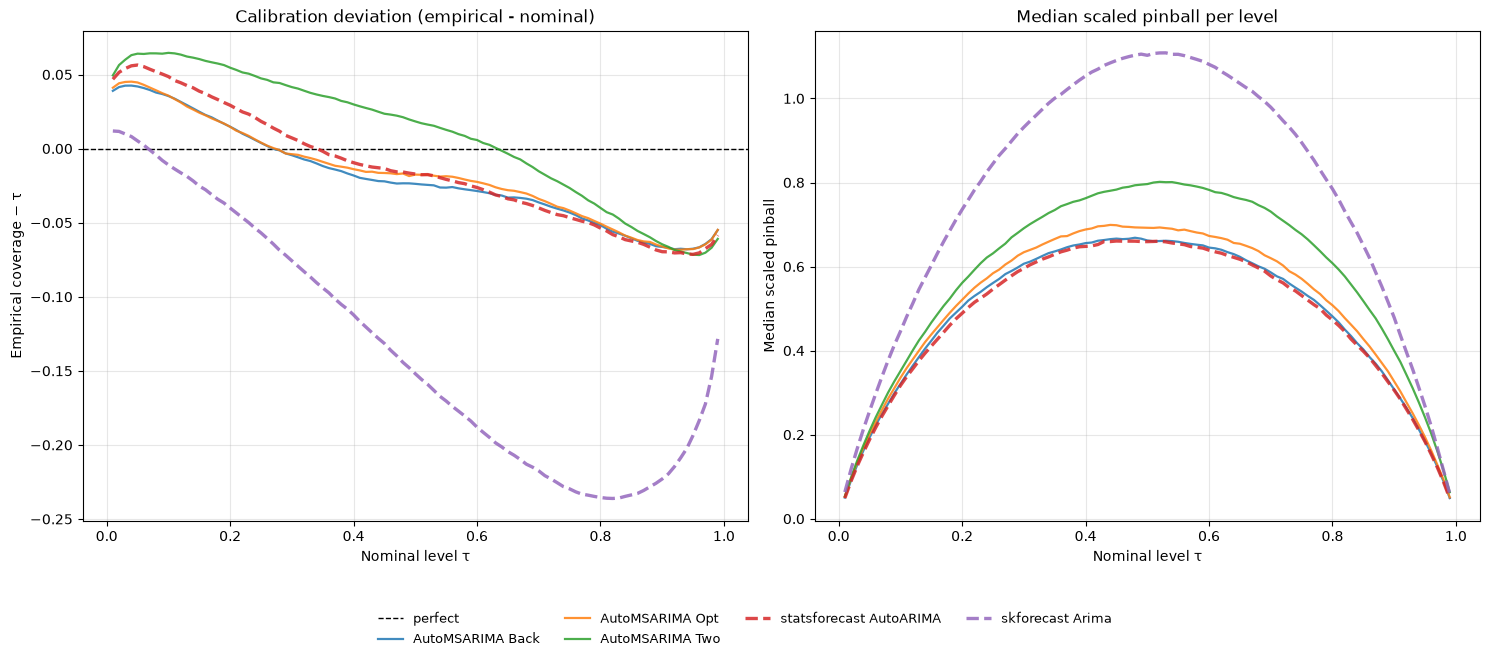

In [6]:
import matplotlib.pyplot as plt
# Calibration deviation (empirical coverage - nominal): 0 = perfect.
fig, ax = plt.subplots(1, 2, figsize=(15, 6.5))
ax[0].axhline(0.0, color="k", ls="--", lw=1, label="perfect")
for j, name in enumerate(METHOD_NAMES):
    cov = np.nanmean(_cov[j], axis=0)
    if np.all(np.isnan(cov)):
        continue
    sm = name.startswith("AutoMSARIMA")
    ax[0].plot(LEVELS, cov - LEVELS, lw=1.6 if sm else 2.4, ls="-" if sm else "--", alpha=0.85, label=name)
    ax[1].plot(LEVELS, np.nanmedian(_pin[j], axis=0), lw=1.6 if sm else 2.4,
               ls="-" if sm else "--", alpha=0.85, label=name)
ax[0].set(title="Calibration deviation (empirical - nominal)", xlabel="Nominal level \u03c4",
          ylabel="Empirical coverage \u2212 \u03c4")
ax[1].set(title="Median scaled pinball per level", xlabel="Nominal level \u03c4",
          ylabel="Median scaled pinball")
ax[0].grid(alpha=0.3); ax[1].grid(alpha=0.3)
handles, labels = ax[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=4, fontsize=9, frameon=False,
           bbox_to_anchor=(0.5, -0.02))
plt.tight_layout(rect=[0, 0.10, 1, 1]); plt.show()
